In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, chisquare
from scipy.optimize import curve_fit
import pandas as pd


In [2]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma**2))

In [ ]:
phase_df.head()

44
--------------------------------------------------
Camera ID: 12574
--------------------------------------------------
Number of Samples: 44
Mean Drift μ: 2.690e-05
Std Dev σ: 5.625e-04
3σ Threshold: 1.687e-03
P(|drift| > 3σ): 3.155e-03
--------------------------------------------------

44
--------------------------------------------------
Camera ID: 12606
--------------------------------------------------
Number of Samples: 44
Mean Drift μ: -1.412e-04
Std Dev σ: 3.709e-04
3σ Threshold: 1.113e-03
P(|drift| > 3σ): 7.230e-04
--------------------------------------------------

44
--------------------------------------------------
Camera ID: 13251
--------------------------------------------------
Number of Samples: 44
Mean Drift μ: -3.428e-04
Std Dev σ: 1.943e-04
3σ Threshold: 5.828e-04
P(|drift| > 3σ): 1.893e-06
--------------------------------------------------

42
--------------------------------------------------
Camera ID: 13703
--------------------------------------------------


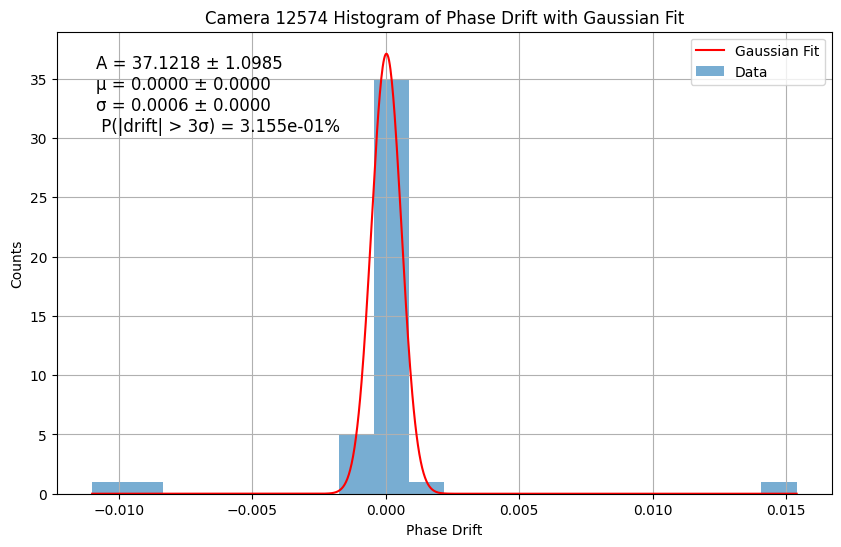

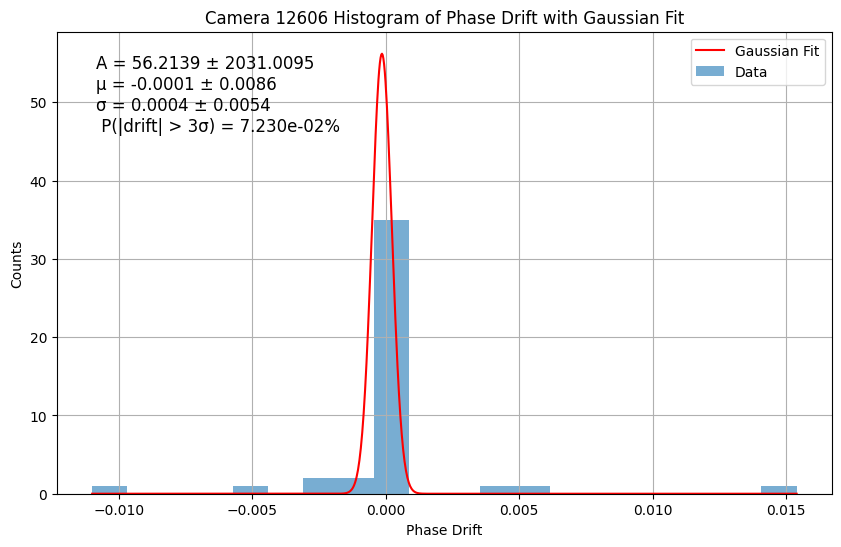

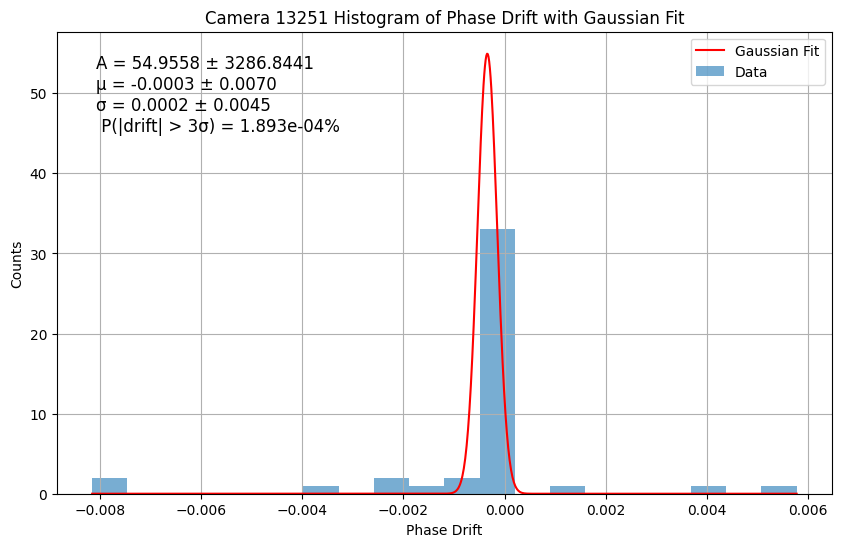

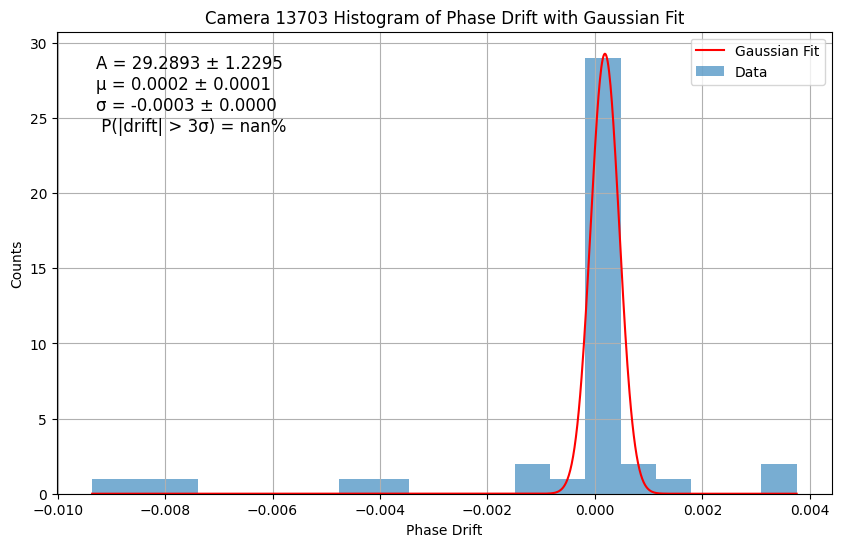

In [ ]:
camera_ids = [12574, 12606, 13251, 13703]
HZ = 5

phase_df = pd.read_csv(f"./fft_phase_analysis/{HZ}Hz/phase_analysis_results.csv")

for id in camera_ids:

    df_data = phase_df[(phase_df["Main Camera"] == id) | (phase_df["Other Camera"] == id)]
    slope = df_data["Slope"].values
    N = len(slope)
    print(len(slope))
    cnts, bin_edges = np.histogram(slope, bins=20, density=False)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2


    popt, pcov = curve_fit(gaussian, bin_centers, cnts, p0=[1, np.mean(slope), np.std(slope)])
    err = np.sqrt(np.diag(pcov))

    A_fit, mu_fit, sigma_fit = popt

    threshold = 3*sigma_fit

    prob_exceed = 2 * (1 - norm.cdf(threshold, loc=mu_fit, scale=sigma_fit))


    print("--------------------------------------------------")
    print(f"Camera ID: {id}")
    print("--------------------------------------------------")

    print(f"Number of Samples: {N}")

    print(f"Mean Drift μ: {mu_fit:.3e}")
    print(f"Std Dev σ: {sigma_fit:.3e}")

    print(f"3σ Threshold: {threshold:.3e}")
    print(f"P(|drift| > 3σ): {prob_exceed:.3e}")


    print("--------------------------------------------------\n")


    x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    y_fit = gaussian(x_fit, *popt)


    plt.figure(figsize=(10, 6))
    plt.bar(bin_centers, cnts, width=bin_edges[1] - bin_edges[0], alpha=0.6, label="Data")
    plt.plot(x_fit, y_fit, color="red", label="Gaussian Fit")
    plt.xlabel("Phase Drift")
    plt.ylabel("Counts")
    plt.title(f"Camera {id} Histogram of Phase Drift with Gaussian Fit")
    plt.legend()
    plt.grid()

    text_str = f"A = {popt[0]:.4f} ± {err[0]:.4f}\nμ = {popt[1]:.4f} ± {err[1]:.4f}\nσ = {popt[2]:.4f} ± {err[2]:.4f}\n P(|drift| > 3σ) = { (prob_exceed * 100):.3e}%"
    plt.text(0.05, 0.95, text_str, transform=plt.gca().transAxes, fontsize=12, verticalalignment="top")
    plt.savefig(f"./fft_phase_analysis/{HZ}Hz/Camera_{id}__Phase_Drift_Fit.png", dpi=300, bbox_inches='tight')

